# Intro to Scikit-Learn
1. End to end SKLearn workflow
2. Getting the data ready
3. Choose the right model (according to the problem in hand)
4. Fit the model to the data and use it to make predictions on our data
5. Evaluating the model
6. Improving the model
7. Save and load the model
8. Putting it all together!

### End to End scikit-learn workflow

In [7]:
import pandas as pd
import numpy as np

heart_disease = pd.read_csv('./data/heart-disease.csv')
heart_disease
heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [17]:
X  = heart_disease.drop('target', axis=1) # X is the feature matrix
y = heart_disease['target'] # y is the target vector

In [ ]:
# Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier

# Create a random forest classifier model
clf = RandomForestClassifier(n_estimators=100)

# see the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [25]:
# 3. Fit the model to the data (train the model)
from sklearn.model_selection import train_test_split

'''
Split the data into training and testing sets.
1. Split the data into X (features) and y (target)
2. Use train_test_split() to split the data into training and testing sets
3. X_train and y_train are training sets
4. X_test and y_test are testing sets 
5. test_size=0.2 means 20% of the data will be used for testing and rest 80% for training.
'''

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train.shape

# Fit the model to the training data
clf.fit(X_train, y_train)

# Make predictions using the trained model
# Use the trained model to make predictions on the test data
y_preds = clf.predict(X_test)
y_preds

array([0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1])

Accuracy on training data: 1.0
Accuracy on testing data: 0.8688524590163934
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.83      0.94      0.88        31

    accuracy                           0.87        61
   macro avg       0.88      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Confusion Matrix:
[[24  6]
 [ 2 29]]
Accuracy Score:
0.8688524590163934


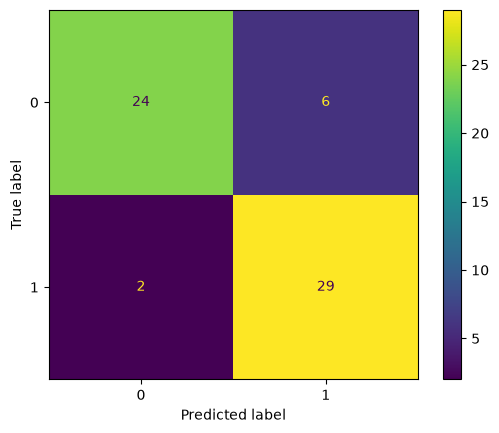

In [36]:
# 5. Evaluate the model on training and testing data

print("Accuracy on training data:", clf.score(X_train, y_train)) # accuracy on training data
print("Accuracy on testing data:", clf.score(X_test, y_test)) # accuracy on testing data


# Checking other evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print('Classification Report:')
print(classification_report(y_test, y_preds))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_preds)
print(cm)

cm_display = ConfusionMatrixDisplay(cm).plot()

print('Accuracy Score:')
print(accuracy_score(y_test, y_preds))


In [37]:
# 5. Improving the model (by changing hyperparameters, using a different model, etc.)

np.random.seed(42)
for i in range(10, 100, 10):
    print(f'Training model with {i} estimators...')
    clf = RandomForestClassifier(n_estimators=i)
    clf.fit(X_train, y_train)
    print(f'Accuracy on training data: {clf.score(X_train, y_train)}')
    print(f'Accuracy on testing data: {clf.score(X_test, y_test)}')
    print('---')


Training model with 10 estimators...
Accuracy on training data: 0.9752066115702479
Accuracy on testing data: 0.819672131147541
---
Training model with 20 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.7868852459016393
---
Training model with 30 estimators...
Accuracy on training data: 0.9958677685950413
Accuracy on testing data: 0.8524590163934426
---
Training model with 40 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.8360655737704918
---
Training model with 50 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.8852459016393442
---
Training model with 60 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.8852459016393442
---
Training model with 70 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.8524590163934426
---
Training model with 80 estimators...
Accuracy on training data: 1.0
Accuracy on testing data: 0.8524590163934426
---
Training model with 90 estimators..

In [41]:
# 6. Save and load a trained model
import pickle 

pickle.dump(clf, open('./models/random_forest_model.pkl', 'wb')) # save the model

# Load the model
loaded_model = pickle.load(open('./models/random_forest_model.pkl', 'rb'))

loaded_model.score(X_test, y_test) # check the accuracy of the loaded model

0.8688524590163934